<a href="https://colab.research.google.com/github/SugiShanmu/Machine-Learning-/blob/main/LassoMultipleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R2: 0.989
RMSE: 2.80

Coefficients (Lasso makes some ZERO):
Area: 22.631
Bedrooms: 0.000
Age: -2.510
Dist_City: -0.000
Loc_Bang: -0.000
Loc_Del: 0.000


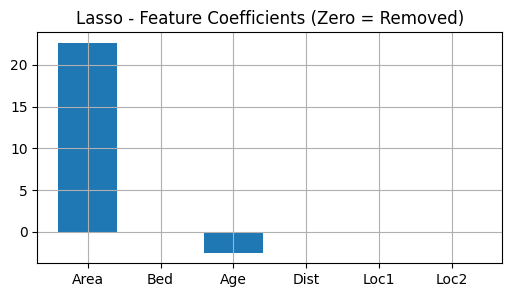


Saved: lasso_regression.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error

# 1. DATA - Many features, some useless
data = {
    'Area': [800,1200,1500,1800,2000,1000,1600,2500,900,1300,2100,1100],
    'Bedrooms': [1,2,3,3,4,2,3,4,1,2,4,2],
    'Age': [5,2,10,3,1,12,4,2,15,6,3,8],
    'Distance_to_City': [10,5,12,3,2,15,4,1,20,7,2,9], # useless feature maybe
    'Location': ['Chennai','Bangalore','Chennai','Delhi','Bangalore','Chennai','Bangalore','Delhi','Chennai','Delhi','Bangalore','Chennai'],
    'Price': [35,55,60,85,95,40,70,120,30,62,98,45]
}
df = pd.DataFrame(data)

X = df.drop('Price', axis=1)
y = df['Price']

# 2. PREPROCESSING - MUST SCALE FOR LASSO!
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['Area','Bedrooms','Age','Distance_to_City']),
    ('cat', OneHotEncoder(drop='first'), ['Location'])
])

# 3. PIPELINE - Lasso (alpha = penalty)
# alpha=0.1 low penalty, alpha=10 high penalty -> more features to zero
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R2: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# 4. SEE FEATURE SELECTION POWER OF LASSO
feature_names = ['Area','Bedrooms','Age','Distance_to_City','Bangalore','Chennai','Delhi'] # after encoding approx
# Get coefficients
coefs = model.named_steps['regressor'].coef_
print("\nCoefficients (Lasso makes some ZERO):")
for name, coef in zip(['Area','Bedrooms','Age','Dist_City','Loc_Bang','Loc_Del'], coefs):
    print(f"{name}: {coef:.3f}")

plt.figure(figsize=(6,3))
plt.bar(['Area','Bed','Age','Dist','Loc1','Loc2'], coefs)
plt.title("Lasso - Feature Coefficients (Zero = Removed)")
plt.grid(True)
plt.show()
plt.savefig("lasso_regression.png")
print("\nSaved: lasso_regression.png")